# Assignment: Linear Regression and Classification

**Name:**

In this assignment you'll practice two core machine learning tasks:

- **Part 1: Linear regression (50 pts).** Predict a car's fuel efficiency from its specs.
- **Part 2: Classification (50 pts).** Predict whether a breast tumor is malignant or benign.
- **Bonus (+5 pts)** at the end.

**How to complete it**

1. Fill in every code cell marked `# TODO`.
2. Answer each written question in the **Your answer** cell below it (2–3 sentences is plenty).
3. Before submitting, restart the kernel and run all cells from top to bottom so every output is visible, then submit this `.ipynb` file.

## Setup
Run this cell first.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    r2_score,
    mean_squared_error,
    accuracy_score,
    precision_score,
    recall_score,
    classification_report,
    ConfusionMatrixDisplay,
)

## Part 1: Predicting fuel efficiency with linear regression (50 pts)

The **Auto MPG** dataset describes car models from 1970 to 1982. Your goal is to predict `mpg` (miles per gallon).

| Column | Meaning |
|---|---|
| `mpg` | Fuel efficiency in miles per gallon (**target**) |
| `cylinders` | Number of engine cylinders |
| `displacement` | Engine size (cubic inches) |
| `horsepower` | Engine horsepower |
| `weight` | Vehicle weight (lbs) |
| `acceleration` | Seconds to go from 0 to 60 mph |
| `model_year` | Model year (70 = 1970) |
| `origin` | Where the car was made: `usa`, `europe`, or `japan` |
| `name` | Car make and model |

In [2]:
df = sns.load_dataset("mpg")  # needs an internet connection the first time
df.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name
0,18.0,8,307.0,130.0,3504,12.0,70,usa,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693,11.5,70,usa,buick skylark 320
2,18.0,8,318.0,150.0,3436,11.0,70,usa,plymouth satellite
3,16.0,8,304.0,150.0,3433,12.0,70,usa,amc rebel sst
4,17.0,8,302.0,140.0,3449,10.5,70,usa,ford torino


### 1.1 Explore the data (5 pts)
How many rows and columns are there, and which columns have missing values? Plot `mpg` against `weight` and against `horsepower`, then describe each relationship: its direction, its strength, and whether it looks straight or curved.

In [3]:
print("Rows, columns:", df.shape)
print()
print("Missing values per column:")
print(df.isna().sum())

Rows, columns: (398, 9)

Missing values per column:
mpg             0
cylinders       0
displacement    0
horsepower      6
weight          0
acceleration    0
model_year      0
origin          0
name            0
dtype: int64


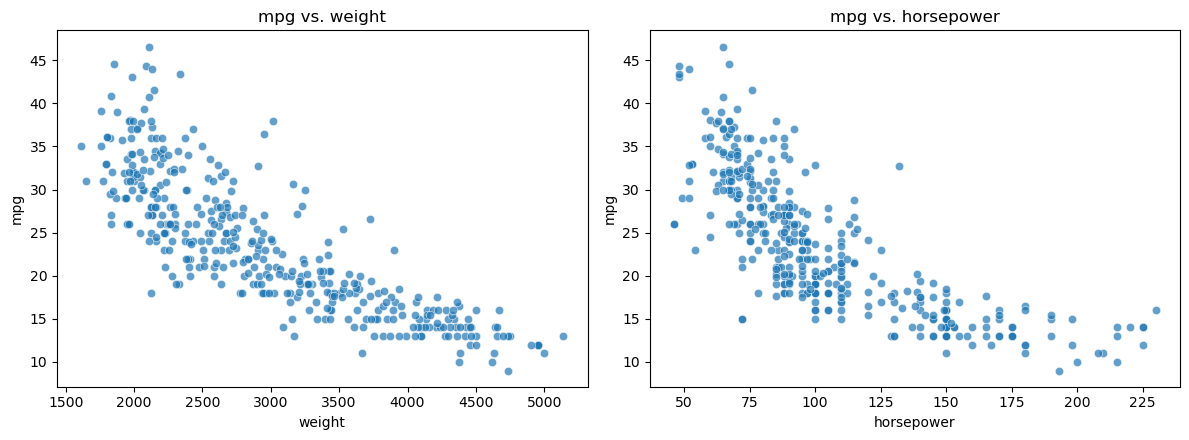

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
sns.scatterplot(data=df, x="weight", y="mpg", ax=axes[0], alpha=0.7)
axes[0].set_title("mpg vs. weight")
sns.scatterplot(data=df, x="horsepower", y="mpg", ax=axes[1], alpha=0.7)
axes[1].set_title("mpg vs. horsepower")
plt.tight_layout()
plt.show()

**Your answer:** There are 398 rows and 9 columns with 6 values missing. From looking at the graphs we can see that there is a negative relationship with an increase in weight leading to a lower MPG. Likewise, with more horsepower there will less MPG. This shows that it is more optimal to have a light car that is around 75 horsepower rather than a heavy car with lots of horsepower.

### 1.2 Clean the data (10 pts)
Handle the missing `horsepower` values (drop or fill them, and justify your choice). Then drop the `name` column and one-hot encode `origin`.

*Hint:* `pd.get_dummies(df, columns=["origin"], drop_first=True)`

In [5]:
# Only a handful of rows are missing horsepower, so dropping them loses very little data
df_clean = df.dropna(subset=["horsepower"]).copy()
df_clean = df_clean.drop(columns="name")
df_clean = pd.get_dummies(df_clean, columns=["origin"], drop_first=True, dtype=int)
print(df_clean.shape)
df_clean.head()

(392, 9)


,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin_japan,origin_usa
0,18.0,8,307.0,130.0,3504,12.0,70,0,1
1,15.0,8,350.0,165.0,3693,11.5,70,0,1
2,18.0,8,318.0,150.0,3436,11.0,70,0,1
3,16.0,8,304.0,150.0,3433,12.0,70,0,1
4,17.0,8,302.0,140.0,3449,10.5,70,0,1


**Your answer** (how did you handle the missing values, and why?): Since there were only 6 rows missing 'horsepower' out of 398, I dropped them because it only made up 1.5% of the data. By doing this, not too much data was lost that could result in the data changing a lot or inventing new data to combat the missing ones. I also dropped 'name' because each car had its own label that you couldn't generalize and organize into quantitative data.

### 1.3 Simple linear regression (10 pts)
Split the data 80/20 with `random_state=42`. Fit a model that predicts `mpg` from `weight` alone, and report its slope, intercept, and test R². Then complete the sentence in the answer cell.

In [6]:
X = df_clean.drop(columns="mpg")
y = df_clean["mpg"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(X_train.shape, X_test.shape)

(313, 8) (79, 8)


In [7]:
simple_model = LinearRegression()
simple_model.fit(X_train[["weight"]], y_train)

print("Slope (mpg per lb):", simple_model.coef_[0])
print("Slope (mpg per 1,000 lbs):", simple_model.coef_[0] * 1000)
print("Intercept:", simple_model.intercept_)
print("Test R²:", r2_score(y_test, simple_model.predict(X_test[["weight"]])))

Slope (mpg per lb): -0.007903610385225607
Slope (mpg per 1,000 lbs): -7.9036103852256065
Intercept: 47.200526427552106
Test R²: 0.6533466675646018


**Your answer:** Each extra 1,000 lbs is associated with a change of about -7.9 mpg.

### 1.4 Multiple linear regression (10 pts)
Using the same split, fit a model on **all** the features in `X_train`, and report its test R² and RMSE.

*Hint:* RMSE = `np.sqrt(mean_squared_error(y_test, y_pred))`

In [8]:
multi_model = LinearRegression()
multi_model.fit(X_train, y_train)
y_pred = multi_model.predict(X_test)

print("Test R²:", r2_score(y_test, y_pred))
print("Test RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))

Test R²: 0.7922774714022583
Test RMSE: 3.256114096847399


### 1.5 Interpret the model (10 pts)
Did the multiple model beat the simple one? Look at its coefficients. Does any sign surprise you, and why might that happen?

*Hint:* check how correlated the features are with each other.

In [9]:
pd.Series(multi_model.coef_, index=X_train.columns).round(4)

cylinders      -0.3421
displacement    0.0192
horsepower     -0.0216
weight         -0.0064
acceleration    0.0422
model_year      0.7972
origin_japan    0.3305
origin_usa     -2.8755
dtype: float64

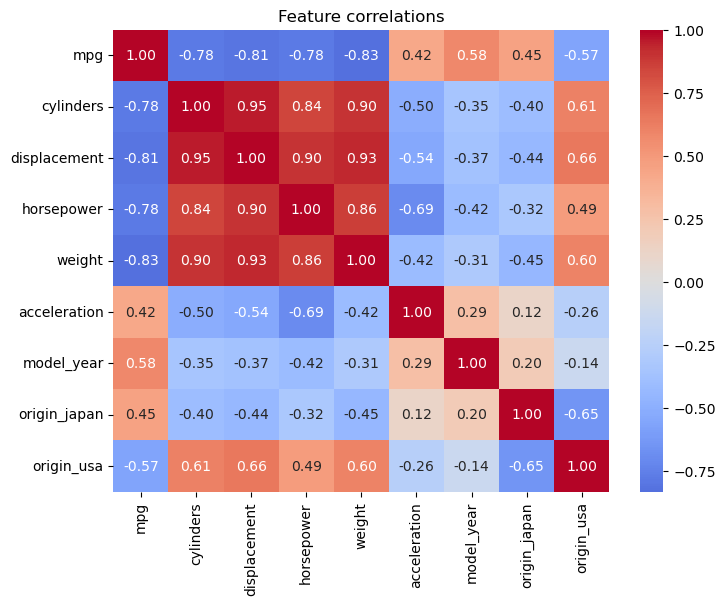

In [10]:
plt.figure(figsize=(8, 6))
sns.heatmap(df_clean.corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Feature correlations")
plt.show()

**Your answer:** Yes, the multiple model improves on the simple one. Looking at the R² test, it rises from 0.65 to 0.79. Its not entirely surprising when looking at the data and seeing the relationships' correlations. I think the biggest surprise was looking at the difference when comparing Japanese brands to American. When comparing the two, they seem to be polar opposites, however, when you think about it, it makes sense. Japanese cars are usually very small and efficient with small engines whereas lots of American cars are big and bulky with a massive v8 gas guzzler engine. It would then make sense when looking at 'cylinder,' 'displacement,' 'horsepower,' 'weight,' and 'acceleration' because when you have a bigger car, it will weighs more which means you need a bigger engine with more horsepower and cylinders, causing the displacement to go higher to combat bigger bores and strokes. 

### 1.6 Check the residuals (5 pts)
For your multiple regression model, plot the residuals (actual − predicted) against the predicted values. Is there a pattern? What does it suggest about using a straight-line model?

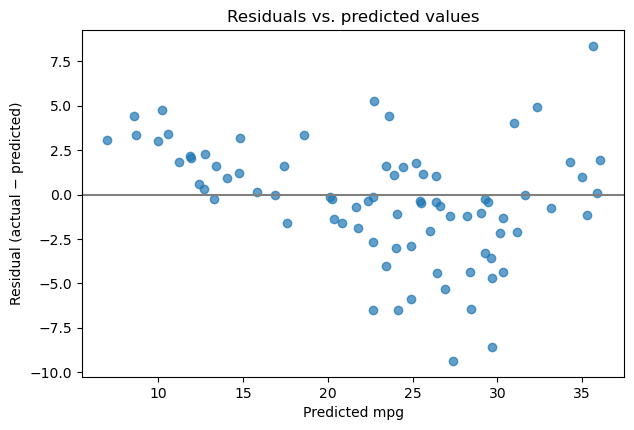

In [11]:
residuals = y_test - y_pred

plt.figure(figsize=(7, 4.5))
plt.scatter(y_pred, residuals, alpha=0.7)
plt.axhline(0, color="gray")
plt.xlabel("Predicted mpg")
plt.ylabel("Residual (actual − predicted)")
plt.title("Residuals vs. predicted values")
plt.show()

**Your answer:** Yes, there is a pattern because it starts off positive for the lowest predicted mpg values, then mostly negative in the middle and upper-middle range, then back to positive again at the high end. The data also seems to be leaning more towards 20+ MPG, therefore, it could be over-predicting.

## Part 2: Diagnosing tumors with classification (50 pts)

In the **Breast Cancer Wisconsin** dataset, each row describes the cell nuclei in a digitized image of a breast tissue sample. The 30 features are the mean, standard error, and "worst" (largest) value of 10 measurements, such as radius, texture, and smoothness.

**Target:** `0` = malignant, `1` = benign

In [12]:
from sklearn.datasets import load_breast_cancer

data = load_breast_cancer(as_frame=True)
X, y = data.data, data.target  # 0 = malignant, 1 = benign
X.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


### 2.1 Explore the data (5 pts)
How many tumors are in each class, and is the dataset balanced?

In [13]:
counts = y.value_counts()
print(counts)
print()
print(data.target_names, "-> 0 and 1")
print((counts / len(y)).round(3))

target
1    357
0    212
Name: count, dtype: int64

['malignant' 'benign'] -> 0 and 1
target
1    0.627
0    0.373
Name: count, dtype: float64


**Your answer:** Benign is set as class 1 with there being 357 cases compared to malignant being 212, therefore, about 63% of the data is benign and 37% being malignant.

### 2.2 Split and scale (10 pts)
Split the data 80/20 with `stratify=y` and `random_state=42`. Then scale the features with `StandardScaler`, fitting it on the training set only. In the answer cell, explain in one sentence why the scaler is fit only on the training set.

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)
print(X_train.shape, X_test.shape)
print(y_train.value_counts(normalize=True).round(3).to_dict(),
      y_test.value_counts(normalize=True).round(3).to_dict())

(455, 30) (114, 30)
{1: 0.626, 0: 0.374} {1: 0.632, 0: 0.368}


In [15]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)  # fit on training data only
X_test_scaled = scaler.transform(X_test)        # reuse the training mean/std

**Your answer:** We don't want the information from the test set, like the mean and standard deviation, make the training set become over-confident and overstate information that would reflect an inaccurate performance on new patients. 

### 2.3 Logistic regression (5 pts)
Train a logistic regression model on the scaled training data and report its test accuracy.

In [16]:
log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train_scaled, y_train)
y_pred = log_model.predict(X_test_scaled)

print("Test accuracy:", accuracy_score(y_test, y_pred))

Test accuracy: 0.9824561403508771


/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:451: OptimizeWarning: Unknown solver options: iprint
  opt_res = optimize.minimize(


### 2.4 Confusion matrix (10 pts)
Plot the confusion matrix and explain what each of the four cells means for a patient.

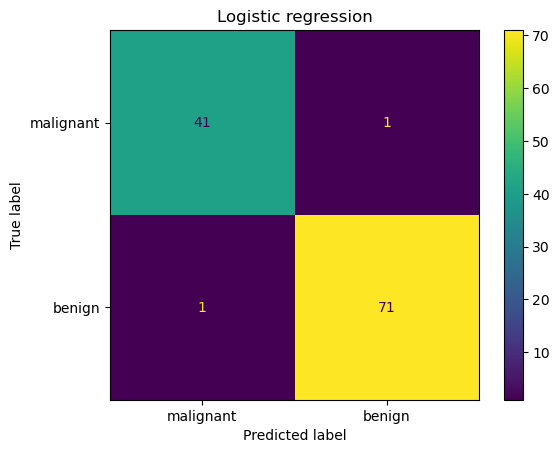

In [17]:
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred, display_labels=data.target_names)
plt.title("Logistic regression")
plt.show()

**Your answer:** By examining the logistic regression, we can see it reached a test accuracy score of about 98.2% which means 112 of the 114 test tumors are classified correctly. When looking at the matrix, we can see that we have successfully flagged 41 patients that should get follow-ups and treatment. 1 patient received a false negative meaning that they have a malignant tumor who was missed and could possibly go untreated. Furthermore, there are 71 patients that are clean and don't need treatment with 1 patient receiving a false positive. This person is completely healthy and was told they may have cancer and has to do more tests and worry more.

### 2.5 Precision and recall (10 pts)
Report precision and recall for the **malignant** class. Which mistake is worse here: a false negative (missing a malignant tumor) or a false positive (flagging a benign tumor as malignant)? Why?

*Heads-up:* sklearn scores class `1` (benign) by default. Pass `pos_label=0` to `precision_score` and `recall_score`, or read the malignant row of `classification_report`.

In [18]:
print("Malignant precision:", precision_score(y_test, y_pred, pos_label=0))
print("Malignant recall:   ", recall_score(y_test, y_pred, pos_label=0))
print()
print(classification_report(y_test, y_pred, target_names=data.target_names))

Malignant precision: 0.9761904761904762
Malignant recall:    0.9761904761904762

              precision    recall  f1-score   support

   malignant       0.98      0.98      0.98        42
      benign       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



**Your answer:** For the malignant class, the precision is about 0.976 which means 97.6% actually were malignant tumors and recall is about 0.976 because the model was able to find 41 of the 42 malignant tumors. A false negative is definitely worse than a false positive because with a false positive that person might worry a little more and has to do extra assessments just to find out they don't actually have cancer. However, with a false negative, that person needs medical treatment and by stating she is healthy, she won't know that she has a serious health problems that need addressing.

### 2.6 Compare with another model (10 pts)
Train one other classifier you've learned, such as k-NN or a decision tree, on the same scaled training data, and compare it with logistic regression. Which model would you trust in a real clinic, and why?

In [19]:
knn = KNeighborsClassifier()
knn.fit(X_train_scaled, y_train)
knn_pred = knn.predict(X_test_scaled)

tree = DecisionTreeClassifier(random_state=42)
tree.fit(X_train_scaled, y_train)
tree_pred = tree.predict(X_test_scaled)

rows = []
for name, pred in [("Logistic regression", y_pred), ("k-NN (k=5)", knn_pred), ("Decision tree", tree_pred)]:
    rows.append({
        "model": name,
        "accuracy": accuracy_score(y_test, pred),
        "malignant precision": precision_score(y_test, pred, pos_label=0),
        "malignant recall": recall_score(y_test, pred, pos_label=0),
        "missed malignant (FN)": int(((y_test == 0) & (pred == 1)).sum()),
    })
pd.DataFrame(rows).set_index("model").round(3)

,accuracy,malignant precision,malignant recall,missed malignant (FN)
model,,,,
Logistic regression,0.982,0.976,0.976,1
k-NN (k=5),0.956,0.951,0.929,3
Decision tree,0.912,0.848,0.929,3


**Your answer:** The model I would want to choose would be the logistic regression. All the numbers show that the logistic regression model with its accuracy, precision, and recall are all better by a good margin. It also shows that fewer people will be affected with only one person compared to 3 for both k-NN and the decision tree, meaning that the logistic regression model can help 2 more people compared to k-NN and decision tree.

## Bonus: Change the decision threshold (+5 pts)
By default, the model predicts malignant when the probability of malignant is above 0.5. Instead, flag a tumor as malignant whenever that probability is above **0.3**. How do precision and recall for the malignant class change, and would you recommend the new threshold for a real clinic?

*Hint:* column 0 of `predict_proba` is the probability of malignant, and `np.where(condition, 0, 1)` turns a condition into labels.

Threshold 0.3
  Malignant precision: 0.8913043478260869
  Malignant recall:    0.9761904761904762
  Accuracy:            0.9473684210526315
Threshold 0.5 (for comparison)
  Malignant precision: 0.9761904761904762
  Malignant recall:    0.9761904761904762
  Accuracy:            0.9824561403508771


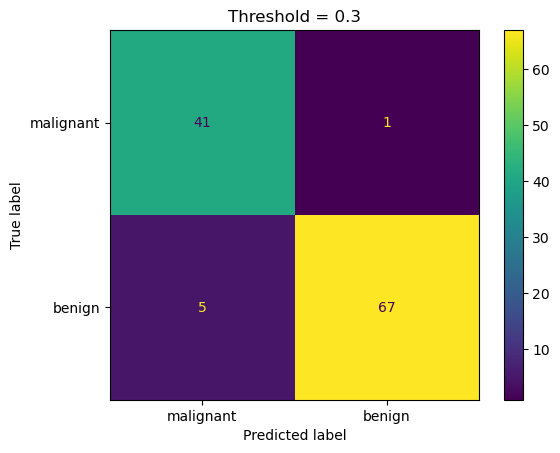

In [20]:
p_malignant = log_model.predict_proba(X_test_scaled)[:, 0]
y_pred_03 = np.where(p_malignant > 0.3, 0, 1)

print("Threshold 0.3")
print("  Malignant precision:", precision_score(y_test, y_pred_03, pos_label=0))
print("  Malignant recall:   ", recall_score(y_test, y_pred_03, pos_label=0))
print("  Accuracy:           ", accuracy_score(y_test, y_pred_03))
print("Threshold 0.5 (for comparison)")
print("  Malignant precision:", precision_score(y_test, y_pred, pos_label=0))
print("  Malignant recall:   ", recall_score(y_test, y_pred, pos_label=0))
print("  Accuracy:           ", accuracy_score(y_test, y_pred))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_03, display_labels=data.target_names)
plt.title("Threshold = 0.3")
plt.show()

**Your answer:** By lowering the threshold to 0.3, it makes the model worse and less precise in classifying the patients. Although the malignant recall stayed the same at 0.976, the precision dropped to 0.891, as well as accuracy falling to 0.947. By lowering the threshold to 0.3, there has been an increase in false negative by 4 instead of 1, therefore, by lowering the threshold, not only has it not benefitted in recall and precision, it told 5 patients that they don't need medical attention when they actually do. I would not recommend this new threshold, especially with what is at stake, and would rather recommend the previous model. 

## Before you submit
- Every `# TODO` cell is filled in and runs without errors.
- Every **Your answer** cell is filled in.
- You restarted the kernel and ran all cells from top to bottom.